In [3]:
# STEP 0 - Setup
# Goal: prepare libraries and strategy parameters.

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")

# --- Strategy parameters (editable) ---
SYMBOL = "XAUUSD"
TF_FAST = "M1"
TF_SLOW = "M15"

EMA_PERIOD = 200
LOOKBACK_SWEEP = 20           # old high/low lookback for "trick move"
RISK_REWARD = 1.5             # TP = SL * RISK_REWARD
PIP_VALUE = 0.1               # for XAUUSD, 1 pip often approximated as 0.1
TP_PIPS_MIN = 10              # beginner style quick target range
TP_PIPS_MAX = 15
FIXED_TP_PIPS = 12            # pick a fixed value inside 10-15 range

START_CAPITAL = 1000.0
RISK_PER_TRADE = 0.01         # 1% risk per trade

print("Setup complete.")
print(f"Symbol={SYMBOL}, Timeframes={TF_FAST}/{TF_SLOW}")

Setup complete.
Symbol=XAUUSD, Timeframes=M1/M15


In [4]:
# STEP 1 - Load data from cache: ./data/<symbol>/<timeframe>
# Explanation:
# We read OHLCV data from local cache folders so no API fetch is needed.


def _standardize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize columns to: open, high, low, close, volume with datetime index."""
    # handle common column variants
    rename_map = {
        "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume",
        "o": "open", "h": "high", "l": "low", "c": "close", "v": "volume",
        "tick_volume": "volume"
    }
    df = df.rename(columns=rename_map)

    # infer datetime index if not already datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        datetime_candidates = [c for c in ["datetime", "date", "time", "timestamp"] if c in df.columns]
        if datetime_candidates:
            dt_col = datetime_candidates[0]
            df[dt_col] = pd.to_datetime(df[dt_col], utc=False, errors="coerce")
            df = df.set_index(dt_col)
        else:
            # fallback for unnamed first column that might hold datetime
            first_col = df.columns[0]
            maybe_dt = pd.to_datetime(df[first_col], utc=False, errors="coerce")
            if maybe_dt.notna().mean() > 0.8:
                df[first_col] = maybe_dt
                df = df.set_index(first_col)

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("Could not build DatetimeIndex from cached file.")

    needed = ["open", "high", "low", "close"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing OHLC columns: {missing}")

    if "volume" not in df.columns:
        df["volume"] = 1.0

    out = df[["open", "high", "low", "close", "volume"]].copy()
    out = out.sort_index().dropna()
    return out


def load_cached_timeframe(symbol: str, timeframe: str, base_dir: str = "./data") -> pd.DataFrame:
    """Load the newest CSV/Parquet file from ./data/<symbol>/<timeframe>."""
    folder = Path(base_dir) / symbol / timeframe
    if not folder.exists():
        raise FileNotFoundError(f"Cache folder not found: {folder}")

    candidates = sorted(
        [*folder.glob("*.parquet"), *folder.glob("*.csv")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No cached data file found in: {folder}")

    path = candidates[0]
    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path)

    df = _standardize_ohlcv(df)
    print(f"Loaded {len(df):,} rows from: {path}")
    return df


# load both timeframes
m1 = load_cached_timeframe(SYMBOL, TF_FAST)
m15 = load_cached_timeframe(SYMBOL, TF_SLOW)

print("\nM1 sample:")
display(m1.head(3))
print("\nM15 sample:")
display(m15.head(3))

Loaded 50,000 rows from: data\XAUUSD\M1\ohlcv.csv
Loaded 50,000 rows from: data\XAUUSD\M15\ohlcv.csv

M1 sample:


,open,high,low,close,volume
time,,,,,
2026-03-18 16:52:00+00:00,4867.61,4868.94,4865.06,4865.17,245
2026-03-18 16:53:00+00:00,4865.11,4865.20,4860.94,4861.50,256
2026-03-18 16:54:00+00:00,4861.48,4865.46,4861.48,4864.17,254



M15 sample:


,open,high,low,close,volume
time,,,,,
2024-03-27 09:15:00+00:00,2179.21,2180.05,2178.61,2179.99,1192
2024-03-27 09:30:00+00:00,2179.99,2180.03,2178.59,2179.21,795
2024-03-27 09:45:00+00:00,2179.21,2180.75,2179.10,2180.49,1015


In [5]:
# STEP 2 - Bigger picture filter (15m + EMA200)
# Explanation:
# If price is above EMA200, we only allow BUY bias.
# If price is below EMA200, we only allow SELL bias.

m15_feat = m15.copy()
m15_feat["ema200"] = m15_feat["close"].ewm(span=EMA_PERIOD, adjust=False).mean()

m15_feat["trend_bias"] = np.where(
    m15_feat["close"] > m15_feat["ema200"],
    "buy_only",
    "sell_only"
)

print("Trend bias distribution:")
print(m15_feat["trend_bias"].value_counts())

display(m15_feat[["close", "ema200", "trend_bias"]].tail(5))

Trend bias distribution:
trend_bias
buy_only     30202
sell_only    19798
Name: count, dtype: int64


,close,ema200,trend_bias
time,,,
2026-05-08 22:45:00+00:00,4724.04,4703.598661,buy_only
2026-05-08 23:00:00+00:00,4718.86,4703.750515,buy_only
2026-05-08 23:15:00+00:00,4717.37,4703.886032,buy_only
2026-05-08 23:30:00+00:00,4716.31,4704.009654,buy_only
2026-05-08 23:45:00+00:00,4715.75,4704.126473,buy_only


In [6]:
# STEP 3 - Detect the "trick move" (liquidity sweep style)
# Explanation:
# SELL trap: price wicks above old high but closes back below that old high.
# BUY trap : price wicks below old low but closes back above that old low.

m15_feat["old_high"] = m15_feat["high"].rolling(LOOKBACK_SWEEP).max().shift(1)
m15_feat["old_low"] = m15_feat["low"].rolling(LOOKBACK_SWEEP).min().shift(1)

m15_feat["trap_sell_15m"] = (
    (m15_feat["high"] > m15_feat["old_high"]) &
    (m15_feat["close"] < m15_feat["old_high"])
)

m15_feat["trap_buy_15m"] = (
    (m15_feat["low"] < m15_feat["old_low"]) &
    (m15_feat["close"] > m15_feat["old_low"])
)

print("Trick move counts:")
print({
    "trap_sell_15m": int(m15_feat["trap_sell_15m"].sum()),
    "trap_buy_15m": int(m15_feat["trap_buy_15m"].sum())
})

display(m15_feat[["high", "low", "close", "old_high", "old_low", "trap_sell_15m", "trap_buy_15m"]].tail(8))

Trick move counts:
{'trap_sell_15m': 3456, 'trap_buy_15m': 2528}


,high,low,close,old_high,old_low,trap_sell_15m,trap_buy_15m
time,,,,,,,
2026-05-08 22:00:00+00:00,4725.72,4720.91,4723.71,4749.55,4701.94,False,False
2026-05-08 22:15:00+00:00,4725.11,4723.38,4723.72,4733.88,4701.94,False,False
2026-05-08 22:30:00+00:00,4726.76,4721.88,4725.29,4728.69,4701.94,False,False
2026-05-08 22:45:00+00:00,4725.82,4723.02,4724.04,4728.69,4701.94,False,False
2026-05-08 23:00:00+00:00,4724.30,4717.04,4718.86,4728.69,4701.94,False,False
2026-05-08 23:15:00+00:00,4719.42,4715.33,4717.37,4728.69,4701.94,False,False
2026-05-08 23:30:00+00:00,4719.27,4715.72,4716.31,4728.69,4701.94,False,False
2026-05-08 23:45:00+00:00,4716.76,4714.39,4715.75,4728.69,4701.94,False,False


In [7]:
# STEP 4 - Move to 1m chart and confirm with VWAP + rejection candle
# Explanation:
# We compute intraday VWAP and check for failed continuation.
# SELL confirm: candle closes below VWAP with an upper wick.
# BUY confirm : candle closes above VWAP with a lower wick.

m1_feat = m1.copy()

# Session VWAP reset each date
typical_price = (m1_feat["high"] + m1_feat["low"] + m1_feat["close"]) / 3.0
session = m1_feat.index.date
cum_pv = (typical_price * m1_feat["volume"]).groupby(session).cumsum()
cum_v = m1_feat["volume"].groupby(session).cumsum().replace(0, np.nan)
m1_feat["vwap"] = cum_pv / cum_v

# candle anatomy
body = (m1_feat["close"] - m1_feat["open"]).abs()
upper_wick = m1_feat["high"] - m1_feat[["open", "close"]].max(axis=1)
lower_wick = m1_feat[["open", "close"]].min(axis=1) - m1_feat["low"]

m1_feat["confirm_sell_1m"] = (
    (m1_feat["close"] < m1_feat["vwap"]) &
    (m1_feat["close"] < m1_feat["open"]) &
    (upper_wick > body)
)

m1_feat["confirm_buy_1m"] = (
    (m1_feat["close"] > m1_feat["vwap"]) &
    (m1_feat["close"] > m1_feat["open"]) &
    (lower_wick > body)
)

print("1m VWAP confirmations:")
print({
    "confirm_sell_1m": int(m1_feat["confirm_sell_1m"].sum()),
    "confirm_buy_1m": int(m1_feat["confirm_buy_1m"].sum())
})

display(m1_feat[["open", "high", "low", "close", "vwap", "confirm_sell_1m", "confirm_buy_1m"]].tail(8))

1m VWAP confirmations:
{'confirm_sell_1m': 3273, 'confirm_buy_1m': 4180}


,open,high,low,close,vwap,confirm_sell_1m,confirm_buy_1m
time,,,,,,,
2026-05-08 23:51:00+00:00,4715.02,4715.19,4714.63,4714.97,4717.378579,True,False
2026-05-08 23:52:00+00:00,4714.89,4715.59,4714.62,4715.27,4717.377512,False,False
2026-05-08 23:53:00+00:00,4715.29,4715.31,4714.71,4715.08,4717.376731,False,False
2026-05-08 23:54:00+00:00,4715.08,4715.27,4714.39,4715.24,4717.375959,False,False
2026-05-08 23:55:00+00:00,4715.28,4715.44,4714.77,4715.44,4717.375341,False,False
2026-05-08 23:56:00+00:00,4715.26,4715.78,4715.09,4715.64,4717.374789,False,False
2026-05-08 23:57:00+00:00,4715.19,4715.54,4715.04,4715.32,4717.373889,False,False
2026-05-08 23:58:00+00:00,4715.31,4716.37,4715.18,4715.75,4717.373178,False,False


In [8]:
# STEP 5 - Entry rules (combine 15m bias + 15m trap + 1m VWAP confirm)
# Explanation:
# We align 15m features onto 1m candles and create final buy/sell entry signals.

# align 15m context onto 1m timeline
m15_ctx = m15_feat[["trend_bias", "trap_sell_15m", "trap_buy_15m", "high", "low"]].copy()
m15_ctx = m15_ctx.rename(columns={"high": "m15_high", "low": "m15_low"})

ctx_on_m1 = pd.merge_asof(
    m1_feat.sort_index(),
    m15_ctx.sort_index(),
    left_index=True,
    right_index=True,
    direction="backward"
)

signals = ctx_on_m1.copy()

signals["sell_signal"] = (
    (signals["trend_bias"] == "sell_only") &
    (signals["trap_sell_15m"]) &
    (signals["confirm_sell_1m"])
)

signals["buy_signal"] = (
    (signals["trend_bias"] == "buy_only") &
    (signals["trap_buy_15m"]) &
    (signals["confirm_buy_1m"])
)

print("Entry signals found:")
print({
    "sell_signal": int(signals["sell_signal"].sum()),
    "buy_signal": int(signals["buy_signal"].sum())
})

display(signals[["close", "vwap", "trend_bias", "trap_sell_15m", "trap_buy_15m", "sell_signal", "buy_signal"]].tail(10))

Entry signals found:
{'sell_signal': 17, 'buy_signal': 32}


,close,vwap,trend_bias,trap_sell_15m,trap_buy_15m,sell_signal,buy_signal
time,,,,,,,
2026-05-08 23:49:00+00:00,4715.17,4717.380644,buy_only,False,False,False,False
2026-05-08 23:50:00+00:00,4714.91,4717.379850,buy_only,False,False,False,False
2026-05-08 23:51:00+00:00,4714.97,4717.378579,buy_only,False,False,False,False
2026-05-08 23:52:00+00:00,4715.27,4717.377512,buy_only,False,False,False,False
2026-05-08 23:53:00+00:00,4715.08,4717.376731,buy_only,False,False,False,False
2026-05-08 23:54:00+00:00,4715.24,4717.375959,buy_only,False,False,False,False
2026-05-08 23:55:00+00:00,4715.44,4717.375341,buy_only,False,False,False,False
2026-05-08 23:56:00+00:00,4715.64,4717.374789,buy_only,False,False,False,False
2026-05-08 23:57:00+00:00,4715.32,4717.373889,buy_only,False,False,False,False


In [9]:
# STEP 6 - Backtest (pilot)
# Explanation:
# - Enter on signal candle close.
# - Stop loss above/below recent sweep area (15m high/low).
# - Take profit uses quick beginner target (10-15 pips), fixed to 12 pips here.


def run_backtest(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    trades = []
    equity_curve = []
    capital = START_CAPITAL

    in_position = False
    side = None
    entry = stop = target = qty = np.nan
    entry_time = None

    tp_distance = FIXED_TP_PIPS * PIP_VALUE

    for ts, row in df.iterrows():
        if not in_position:
            # open SELL
            if row.get("sell_signal", False):
                entry = row["close"]
                # protective stop just above sweep region
                stop = max(row.get("m15_high", row["high"]), row["high"])
                sl_distance = max(stop - entry, 1e-6)
                target = entry - max(tp_distance, sl_distance * RISK_REWARD)

                risk_amount = capital * RISK_PER_TRADE
                qty = risk_amount / sl_distance

                in_position = True
                side = "SELL"
                entry_time = ts

            # open BUY
            elif row.get("buy_signal", False):
                entry = row["close"]
                # protective stop just below sweep region
                stop = min(row.get("m15_low", row["low"]), row["low"])
                sl_distance = max(entry - stop, 1e-6)
                target = entry + max(tp_distance, sl_distance * RISK_REWARD)

                risk_amount = capital * RISK_PER_TRADE
                qty = risk_amount / sl_distance

                in_position = True
                side = "BUY"
                entry_time = ts

        else:
            exit_price = None
            exit_reason = None

            if side == "SELL":
                # stop first, then target (conservative intrabar assumption)
                if row["high"] >= stop:
                    exit_price = stop
                    exit_reason = "SL"
                elif row["low"] <= target:
                    exit_price = target
                    exit_reason = "TP"

                if exit_price is not None:
                    pnl = (entry - exit_price) * qty
                    capital += pnl
                    trades.append({
                        "entry_time": entry_time,
                        "exit_time": ts,
                        "side": side,
                        "entry": entry,
                        "stop": stop,
                        "target": target,
                        "exit": exit_price,
                        "qty": qty,
                        "pnl": pnl,
                        "capital_after": capital,
                        "reason": exit_reason,
                    })
                    in_position = False

            elif side == "BUY":
                if row["low"] <= stop:
                    exit_price = stop
                    exit_reason = "SL"
                elif row["high"] >= target:
                    exit_price = target
                    exit_reason = "TP"

                if exit_price is not None:
                    pnl = (exit_price - entry) * qty
                    capital += pnl
                    trades.append({
                        "entry_time": entry_time,
                        "exit_time": ts,
                        "side": side,
                        "entry": entry,
                        "stop": stop,
                        "target": target,
                        "exit": exit_price,
                        "qty": qty,
                        "pnl": pnl,
                        "capital_after": capital,
                        "reason": exit_reason,
                    })
                    in_position = False

        equity_curve.append((ts, capital))

    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_curve, columns=["time", "equity"]).set_index("time")
    return trades_df, equity_df


trades_df, equity_df = run_backtest(signals)

if len(trades_df) == 0:
    print("No completed trades in pilot backtest. You can loosen rules or use longer data history.")
else:
    wins = (trades_df["pnl"] > 0).sum()
    losses = (trades_df["pnl"] <= 0).sum()
    win_rate = wins / len(trades_df) * 100
    net = trades_df["pnl"].sum()

    print(f"Trades: {len(trades_df)} | Wins: {wins} | Losses: {losses} | Win rate: {win_rate:.1f}%")
    print(f"Net PnL: {net:.2f} | Final capital: {equity_df['equity'].iloc[-1]:.2f}")

    display(trades_df.tail(10))

Trades: 28 | Wins: 9 | Losses: 19 | Win rate: 32.1%
Net PnL: -55.37 | Final capital: 944.63


,entry_time,exit_time,side,entry,stop,target,exit,qty,pnl,capital_after,reason
18,2026-04-21 14:50:00+00:00,2026-04-21 15:05:00+00:00,SELL,4795.78,4797.92,4792.570,4792.57,4.417474,14.180090,959.519452,TP
19,2026-04-24 22:50:00+00:00,2026-04-24 22:56:00+00:00,BUY,4716.78,4713.76,4721.310,4713.76,3.177217,-9.595195,949.924257,SL
20,2026-04-24 22:59:00+00:00,2026-04-24 23:01:00+00:00,BUY,4717.24,4713.76,4722.460,4713.76,2.729667,-9.499243,940.425014,SL
21,2026-04-28 20:31:00+00:00,2026-04-28 20:42:00+00:00,SELL,4594.69,4601.50,4584.475,4601.50,1.380947,-9.404250,931.020764,SL
22,2026-04-28 20:44:00+00:00,2026-04-28 20:56:00+00:00,SELL,4599.02,4601.50,4595.300,4595.30,3.754116,13.965311,944.986076,TP
23,2026-04-30 17:11:00+00:00,2026-04-30 19:16:00+00:00,BUY,4617.51,4609.52,4629.495,4609.52,1.182711,-9.449861,935.536215,SL
24,2026-04-30 19:45:00+00:00,2026-04-30 19:50:00+00:00,BUY,4609.50,4605.22,4615.920,4615.92,2.185832,14.033043,949.569258,TP
25,2026-04-30 19:52:00+00:00,2026-04-30 19:57:00+00:00,BUY,4614.36,4605.22,4628.070,4605.22,1.038916,-9.495693,940.073566,SL
26,2026-05-07 18:45:00+00:00,2026-05-07 18:58:00+00:00,BUY,4739.40,4726.38,4758.930,4726.38,0.722023,-9.400736,930.672830,SL
27,2026-05-08 01:00:00+00:00,2026-05-08 01:22:00+00:00,BUY,4686.74,4678.42,4699.220,4699.22,1.118597,13.960092,944.632922,TP


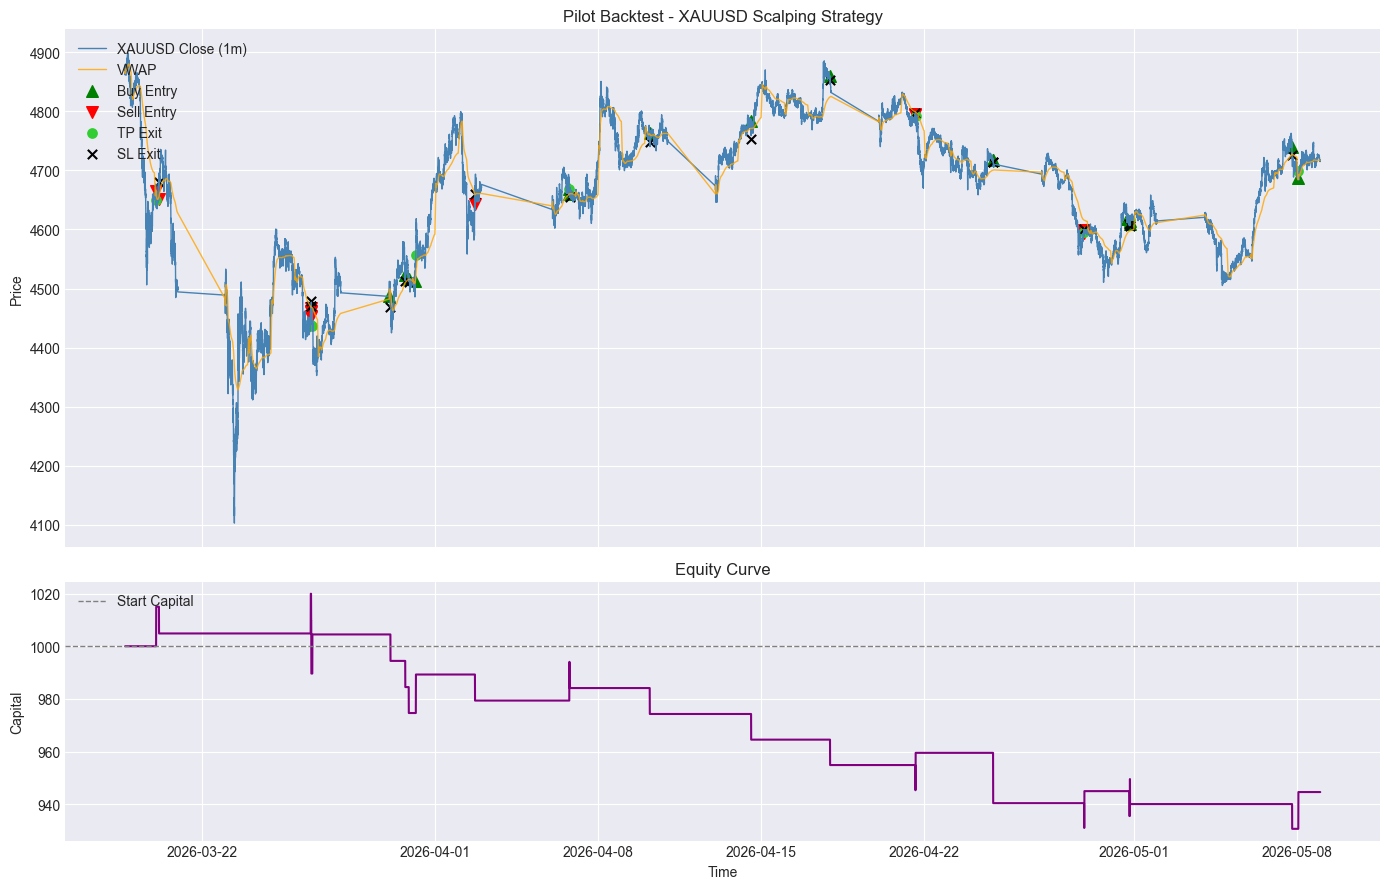


Pilot result snapshot:
   side                entry_time                 exit_time    entry     exit  \
23  BUY 2026-04-30 17:11:00+00:00 2026-04-30 19:16:00+00:00  4617.51  4609.52   
24  BUY 2026-04-30 19:45:00+00:00 2026-04-30 19:50:00+00:00  4609.50  4615.92   
25  BUY 2026-04-30 19:52:00+00:00 2026-04-30 19:57:00+00:00  4614.36  4605.22   
26  BUY 2026-05-07 18:45:00+00:00 2026-05-07 18:58:00+00:00  4739.40  4726.38   
27  BUY 2026-05-08 01:00:00+00:00 2026-05-08 01:22:00+00:00  4686.74  4699.22   

          pnl reason  
23  -9.449861     SL  
24  14.033043     TP  
25  -9.495693     SL  
26  -9.400736     SL  
27  13.960092     TP  


In [10]:
# STEP 7 - Pilot result on chart
# Explanation:
# Top chart: 1m close with buy/sell entries and exits.
# Bottom chart: equity curve from pilot backtest.

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

# price chart
axes[0].plot(signals.index, signals["close"], label="XAUUSD Close (1m)", color="steelblue", linewidth=1)
axes[0].plot(signals.index, signals["vwap"], label="VWAP", color="orange", linewidth=1, alpha=0.8)

if len(trades_df) > 0:
    buy_entries = trades_df[trades_df["side"] == "BUY"]
    sell_entries = trades_df[trades_df["side"] == "SELL"]

    axes[0].scatter(buy_entries["entry_time"], buy_entries["entry"], marker="^", s=70, color="green", label="Buy Entry")
    axes[0].scatter(sell_entries["entry_time"], sell_entries["entry"], marker="v", s=70, color="red", label="Sell Entry")

    tp_exits = trades_df[trades_df["reason"] == "TP"]
    sl_exits = trades_df[trades_df["reason"] == "SL"]

    axes[0].scatter(tp_exits["exit_time"], tp_exits["exit"], marker="o", s=45, color="limegreen", label="TP Exit")
    axes[0].scatter(sl_exits["exit_time"], sl_exits["exit"], marker="x", s=45, color="black", label="SL Exit")

axes[0].set_title(f"Pilot Backtest - {SYMBOL} Scalping Strategy")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

# equity chart
axes[1].plot(equity_df.index, equity_df["equity"], color="purple", linewidth=1.5)
axes[1].axhline(START_CAPITAL, color="gray", linestyle="--", linewidth=1, label="Start Capital")
axes[1].set_title("Equity Curve")
axes[1].set_ylabel("Capital")
axes[1].set_xlabel("Time")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

if len(trades_df) > 0:
    print("\nPilot result snapshot:")
    print(trades_df[["side", "entry_time", "exit_time", "entry", "exit", "pnl", "reason"]].tail(5))